# 05 — Études de cas qualitatives

Pour chaque mot cible, on combine :
1. **Tableau des voisins** — top-10 voisins par période (alignement Procrustes)
2. **Trajectoire 2D** — PCA sur les 5 vecteurs alignés + 10 voisins à chaque date
3. **Mise en récit** — hypothèses historiques à valider/invalider

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
from gensim.models import Word2Vec
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid')
Path('../results/figures').mkdir(exist_ok=True)

YEARS = [1973, 1978, 1981, 1988, 1993]
REF_YEAR = 1973

models = {y: Word2Vec.load(f'../results/models/w2v_{y}.model') for y in YEARS}
print('Modèles chargés')

Modèles chargés


## 1. Ré-alignement Procrustes (repris du notebook 04)

In [9]:
def procrustes_align(base_model, other_model):
    common = list(set(base_model.wv.index_to_key) & set(other_model.wv.index_to_key))
    A = np.array([base_model.wv[w]  for w in common])
    B = np.array([other_model.wv[w] for w in common])
    A = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-9)
    B = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-9)
    U, _, Vt = np.linalg.svd(A.T @ B)
    R = U @ Vt
    all_words = other_model.wv.index_to_key
    all_vecs  = np.array([other_model.wv[w] for w in all_words])
    all_vecs  = all_vecs / (np.linalg.norm(all_vecs, axis=1, keepdims=True) + 1e-9)
    return {w: (all_vecs @ R.T)[i] for i, w in enumerate(all_words)}


aligned = {REF_YEAR: {w: models[REF_YEAR].wv[w] /
                       (np.linalg.norm(models[REF_YEAR].wv[w]) + 1e-9)
                       for w in models[REF_YEAR].wv.index_to_key}}
for y in YEARS[1:]:
    aligned[y] = procrustes_align(models[REF_YEAR], models[y])

print('Espaces alignés')


def top_neighbors(year, word, n=10):
    vd = aligned[year]
    if word not in vd:
        return []
    v = vd[word]
    sims = {w: float(v @ vd[w]) for w in vd if w != word}
    return sorted(sims, key=lambda x: -sims[x])[:n]

Espaces alignés


## 2. Tableaux de voisinage par mot cible

In [10]:
MOTS_CIBLES = ['sécurité', 'liberté', 'europe', 'nation', 'travail', 'social', 'immigration']
MOTS_CIBLES = [m for m in MOTS_CIBLES
               if all(m in aligned[y] for y in YEARS)]
print('Mots analysés :', MOTS_CIBLES)

N_VOISINS = 10

for mot in MOTS_CIBLES:
    print(f'\n{'='*60}')
    print(f'  {mot.upper()}')
    print(f'{'='*60}')
    rows = {}
    for y in YEARS:
        rows[y] = top_neighbors(y, mot, n=N_VOISINS)

    # Affichage côte à côte
    header = '  '.join(f'{y}' for y in YEARS)
    print(f'  Rang  {header}')
    for i in range(N_VOISINS):
        line = f'  {i+1:>3}   '
        for y in YEARS:
            w = rows[y][i] if i < len(rows[y]) else ''
            line += f'{w:<22}'
        print(line)

Mots analysés : ['sécurité', 'liberté', 'europe', 'nation', 'travail', 'social', 'immigration']

  SÉCURITÉ
  Rang  1973  1978  1981  1988  1993
    1   hygiène               bandit                bandit                culture               renforcer             
    2   épuration             santé                 ordre                 garantir              police                
    3   égalité               liberté               défense               encourager            réformer              
    4   exigence              confort               citoyen               solidarité            refuser               
    5   consultatif           ordre                 paix                  personne              peine_mort            
    6   licenciement          citoyen               confort               environnement         code_nationalité      
    7   procurer              hygiène               véritable             veiller               promettre             
    8   garantir      

## 3. Trajectoires 2D par mot cible (PCA)

On projette le vecteur du mot cible + ses 8 voisins à chaque date
dans un espace 2D commun via PCA sur l'union de tous ces vecteurs.
La trajectoire du mot montre visuellement sa dérive dans l'espace sémantique.

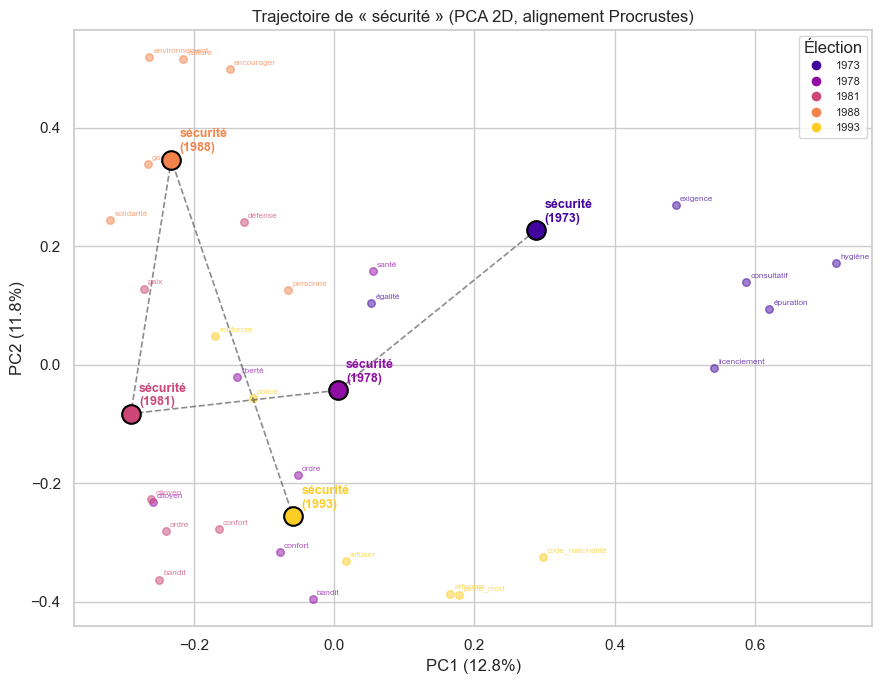

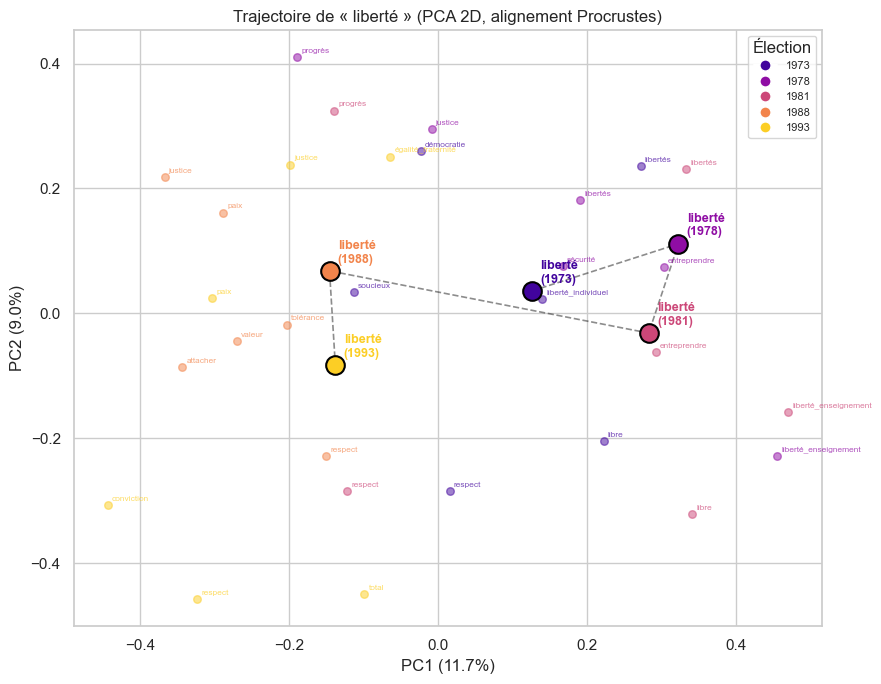

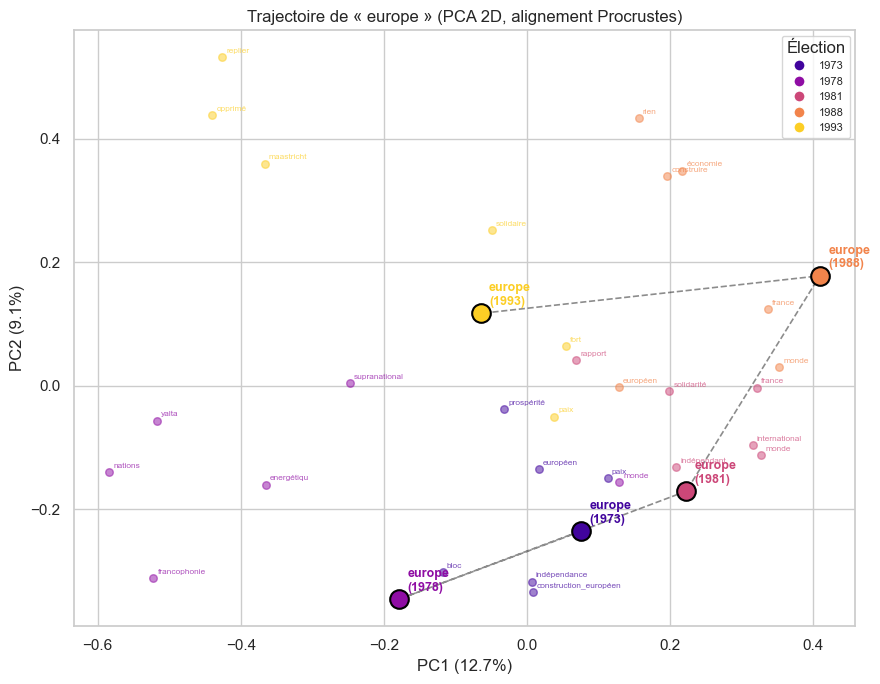

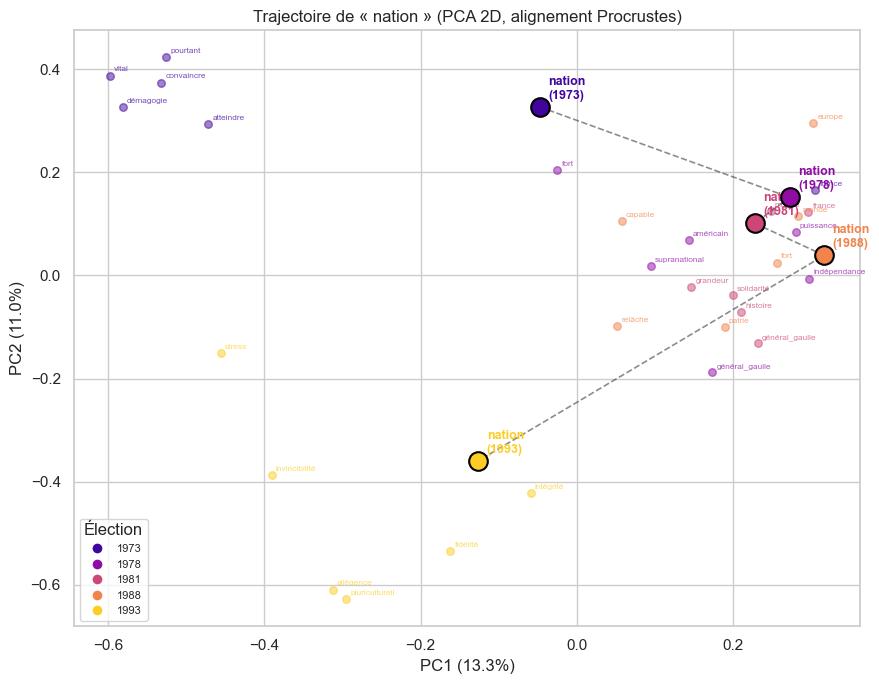

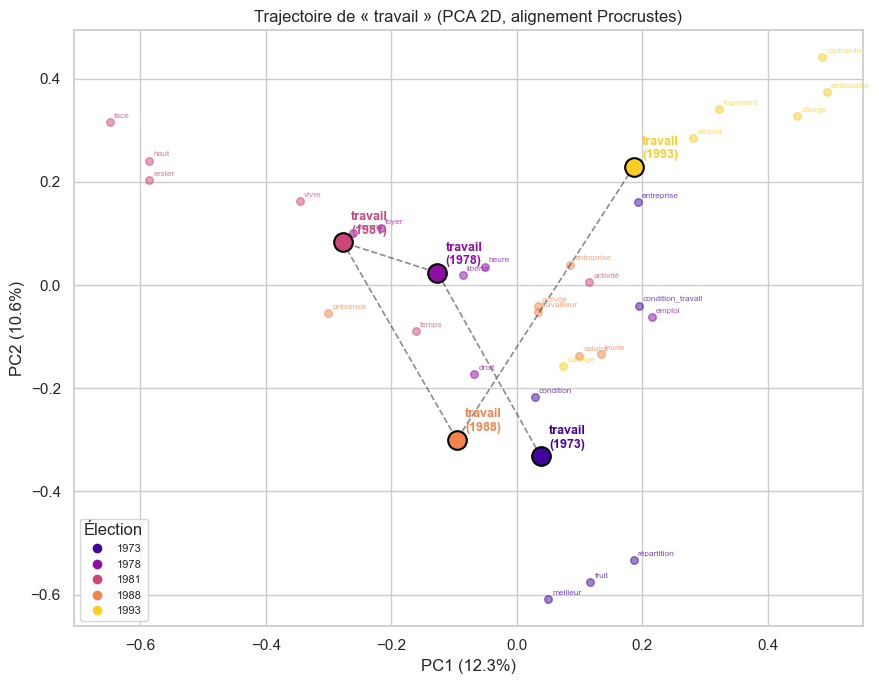

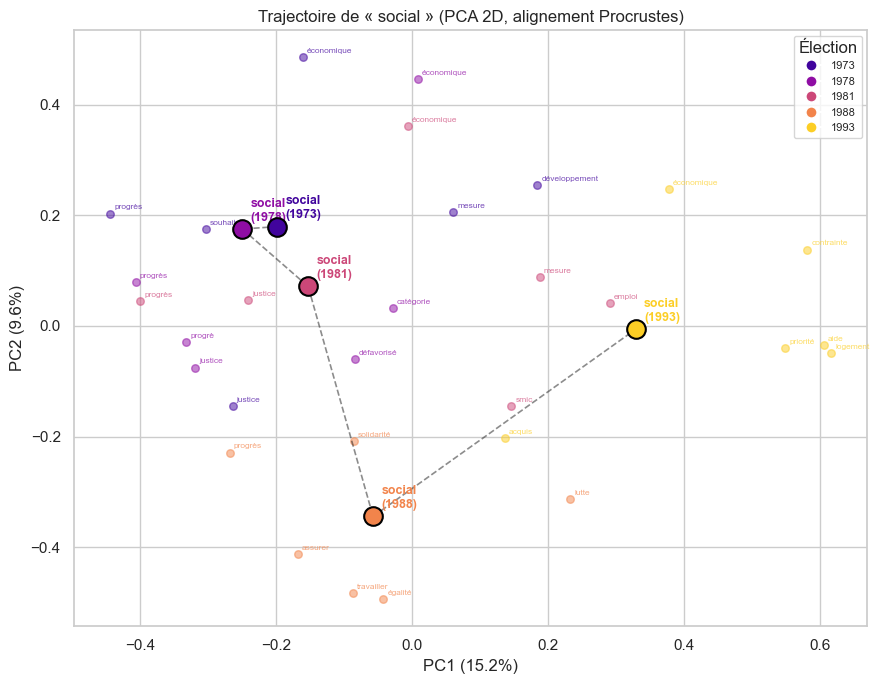

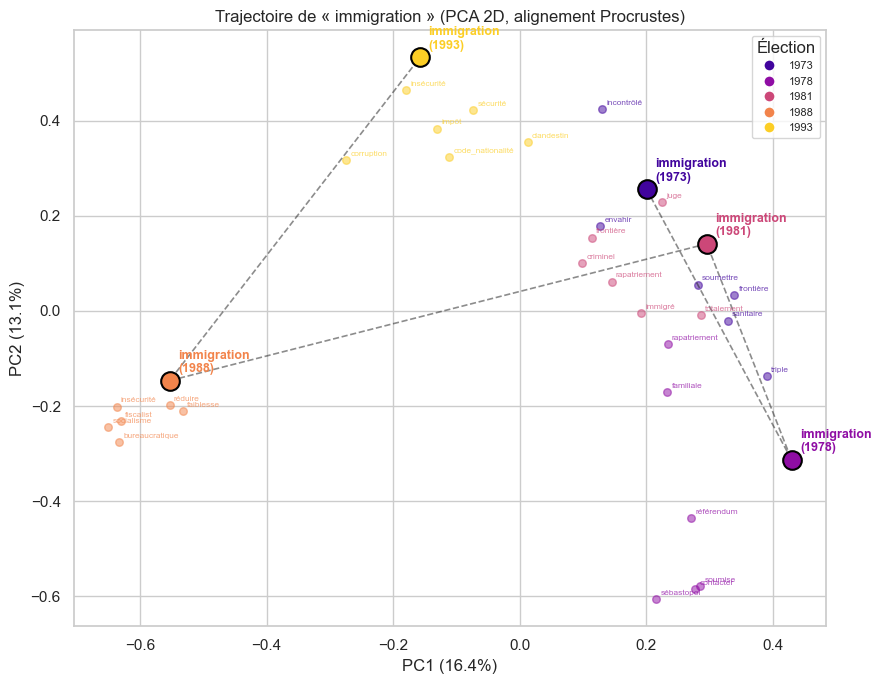

In [11]:
COLORS = plt.cm.plasma(np.linspace(0.1, 0.9, len(YEARS)))
N_CONTEXT = 6   # voisins à afficher autour du mot cible

for mot in MOTS_CIBLES:
    # Collecter tous les mots/vecteurs à projeter
    words_pool, vecs_pool = [], []
    year_labels = {}

    for y in YEARS:
        if mot not in aligned[y]:
            continue
        words_pool.append((y, mot))
        vecs_pool.append(aligned[y][mot])
        for nb in top_neighbors(y, mot, n=N_CONTEXT):
            if nb in aligned[y]:
                words_pool.append((y, nb))
                vecs_pool.append(aligned[y][nb])

    if len(vecs_pool) < 5:
        continue

    pca = PCA(n_components=2)
    coords = pca.fit_transform(np.array(vecs_pool))

    fig, ax = plt.subplots(figsize=(9, 7))

    # Tracer les voisins
    for idx, (y, w) in enumerate(words_pool):
        ci = YEARS.index(y)
        color = COLORS[ci]
        if w == mot:
            ax.scatter(*coords[idx], s=180, color=color, zorder=5,
                       edgecolors='black', linewidths=1.5)
            ax.annotate(f'{mot}\n({y})', coords[idx],
                        textcoords='offset points', xytext=(6, 6),
                        fontsize=9, fontweight='bold', color=color)
        else:
            ax.scatter(*coords[idx], s=30, color=color, alpha=0.5)
            ax.annotate(w, coords[idx],
                        textcoords='offset points', xytext=(3, 3),
                        fontsize=6, alpha=0.7, color=color)

    # Trajectoire du mot cible
    target_coords = [coords[i] for i, (y, w) in enumerate(words_pool) if w == mot]
    if len(target_coords) > 1:
        xs, ys_ = zip(*target_coords)
        ax.plot(xs, ys_, 'k--', lw=1.2, alpha=0.5)

    # Légende années
    from matplotlib.lines import Line2D
    legend_els = [Line2D([0], [0], marker='o', color='w',
                         markerfacecolor=COLORS[i], markersize=8,
                         label=str(y))
                  for i, y in enumerate(YEARS)]
    ax.legend(handles=legend_els, title='Élection', loc='best', fontsize=8)
    ax.set_title(f'Trajectoire de « {mot} » (PCA 2D, alignement Procrustes)')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.tight_layout()
    plt.savefig(f'../results/figures/05_trajectoire_{mot}.png', dpi=150)
    plt.show()

## 4. Zoom — analyse de cadrage : `immigration` et `chômage`

**Hypothèse `immigration`** : bascule d'un cadrage *économique* (ouvrier, travailleur, salaire,
main-d'œuvre étrangère) en 1973-1981 vers un cadrage *identitaire/sécuritaire*
(national, français, frontière, délinquance) en 1988-1993. Lecture historique :
montée du Front National (irruption en 1986/88), lois Pasqua-Méhaignerie, déplacement
du discours politique.

**Hypothèse `chômage`** : co-évolution avec `immigration`. Cadrage *structurel*
(industrie, crise, formation, reconversion) en 1973-1978 vs cadrage de
*responsabilisation* (assistance, allocation, fraude) en 1988-1993.

Méthode : pour chaque cadre, on mesure la similarité cosinus moyenne du mot cible
avec les mots du champ lexical, par période. On observe la trajectoire de bascule
entre les deux cadres concurrents.

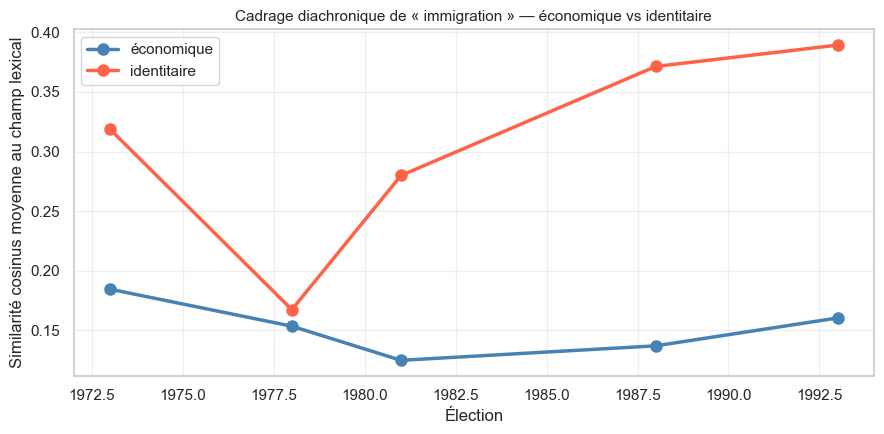


=== IMMIGRATION ===
  économique         1973=0.184  1993=0.160  Δ=-0.024 ↓
  identitaire        1973=0.319  1993=0.389  Δ=+0.071 ↑


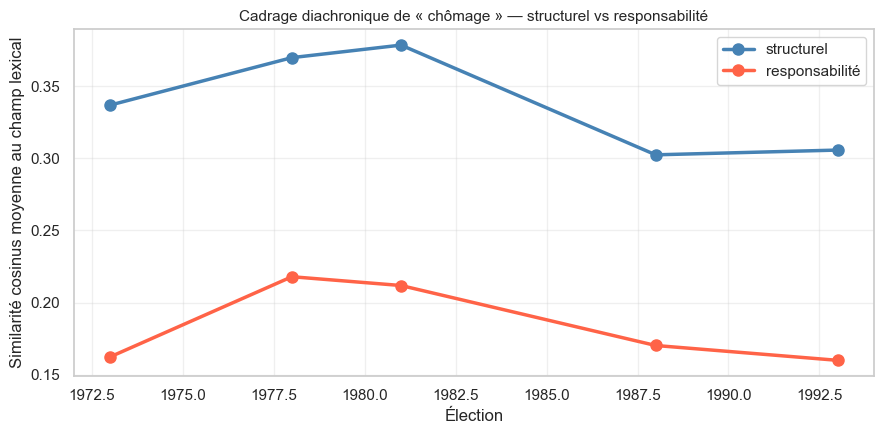


=== CHÔMAGE ===
  structurel         1973=0.337  1993=0.306  Δ=-0.031 ↓
  responsabilité     1973=0.162  1993=0.160  Δ=-0.002 ↓


In [ ]:
CAS = {
    'immigration': {
        'économique':  ['travailleur', 'ouvrier', 'emploi', 'salaire',
                        'industrie', 'usine', 'classe_ouvrier'],
        'identitaire': ['national', 'français', 'france', 'identité',
                        'frontière', 'délinquance', 'sécurité',
                        'criminel', 'code_nationalité'],
    },
    'chômage': {
        'structurel':       ['économie', 'crise', 'industrie', 'investissement',
                             'emploi', 'formation', 'reconversion', 'jeune'],
        'responsabilité':   ['assistance', 'allocation', 'fraude', 'effort',
                             'mérite', 'paresseux', 'profiteur', 'devoir'],
    },
}

def field_coverage(words, year):
    return [w for w in words if w in aligned[year]]


for mot, frames in CAS.items():
    if not all(mot in aligned[y] for y in YEARS):
        print(f'⚠ {mot} absent dans certaines années, skip')
        continue

    fig, ax = plt.subplots(figsize=(9, 4.5))
    colors_frame = ['steelblue', 'tomato']

    for fi, (frame_name, frame_words) in enumerate(frames.items()):
        scores = []
        for y in YEARS:
            v_mot = aligned[y][mot]
            avail = field_coverage(frame_words, y)
            if not avail:
                scores.append(np.nan)
                continue
            sims = [float(v_mot @ aligned[y][w]) for w in avail]
            scores.append(np.mean(sims))
        ax.plot(YEARS, scores, marker='o', label=frame_name,
                color=colors_frame[fi], lw=2.5, markersize=8)

    ax.set_title(f'Cadrage diachronique de « {mot} » — '
                 f'{ " vs ".join(frames.keys()) }', fontsize=11)
    ax.set_xlabel('Élection')
    ax.set_ylabel('Similarité cosinus moyenne au champ lexical')
    ax.legend(loc='best')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'../results/figures/05_cadrage_{mot}.png', dpi=150)
    plt.show()

    # Résumé textuel
    print(f'\n=== {mot.upper()} ===')
    for frame_name, frame_words in frames.items():
        avail_1973 = field_coverage(frame_words, 1973)
        avail_1993 = field_coverage(frame_words, 1993)
        s73 = np.mean([float(aligned[1973][mot] @ aligned[1973][w])
                       for w in avail_1973]) if avail_1973 else np.nan
        s93 = np.mean([float(aligned[1993][mot] @ aligned[1993][w])
                       for w in avail_1993]) if avail_1993 else np.nan
        delta = s93 - s73
        symbol = '↑' if delta > 0 else '↓'
        print(f'  {frame_name:<18} 1973={s73:.3f}  1993={s93:.3f}  Δ={delta:+.3f} {symbol}')

## 6. Drift Jaccard — stabilité du voisinage

Le drift Jaccard mesure le taux de renouvellement des voisins entre 1973 et chaque
date ultérieure. Un Jaccard élevé (proche de 1) indique que la quasi-totalité
des voisins a changé → rupture sémantique.

On le compare au drift cosinus : un mot peut dériver dans l'espace continu
tout en conservant les mêmes voisins (drift cosinus fort, Jaccard faible),
ou bien changer radicalement de voisinage avec peu de déplacement vectoriel.

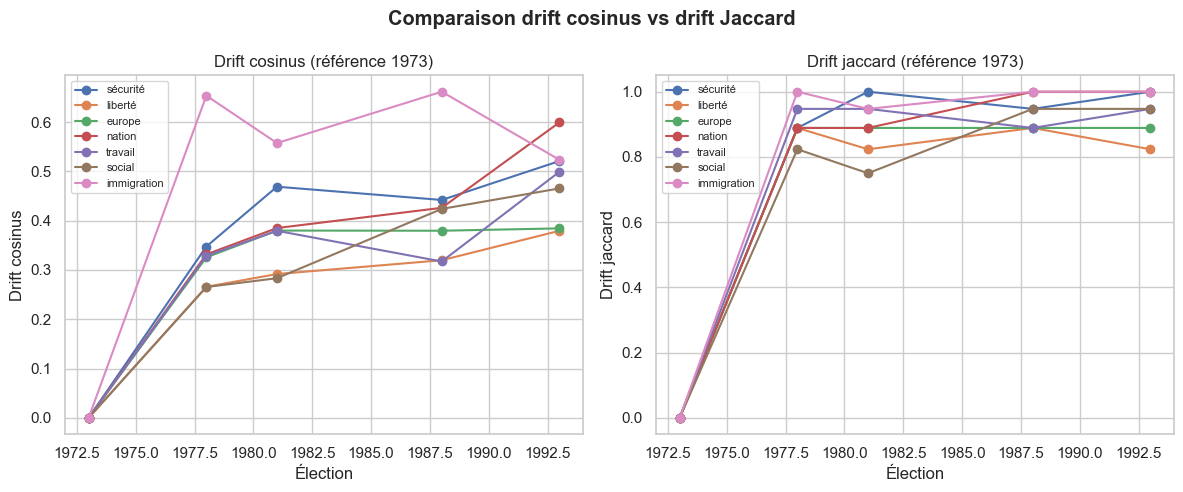

In [14]:
def jaccard_drift(year, mot, ref_neighbors):
    neigh_t = set(top_neighbors(year, mot, n=10))
    ref     = set(ref_neighbors)
    return 1 - len(neigh_t & ref) / len(neigh_t | ref) if neigh_t | ref else 0.0


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric in zip(axes, ['cosinus', 'jaccard']):
    for mot in MOTS_CIBLES:
        if mot not in aligned[REF_YEAR]:
            continue
        ref_neigh = top_neighbors(REF_YEAR, mot, n=10)
        vals = [0.0]
        for y in YEARS[1:]:
            if mot not in aligned[y]:
                vals.append(np.nan)
                continue
            if metric == 'cosinus':
                v = 1 - float(aligned[REF_YEAR][mot] @ aligned[y][mot])
            else:
                v = jaccard_drift(y, mot, ref_neigh)
            vals.append(v)
        ax.plot(YEARS, vals, marker='o', label=mot)

    ax.set_title(f'Drift {metric} (référence 1973)')
    ax.set_xlabel('Élection')
    ax.set_ylabel(f'Drift {metric}')
    ax.legend(fontsize=8, loc='upper left')

plt.suptitle('Comparaison drift cosinus vs drift Jaccard', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/05_cos_vs_jaccard.png', dpi=150)
plt.show()